# AC Circuits

Earlier we discussed notation from IEEE and MKS and mentioned that In this book, we use MKS units and IEEE standards as far as possible. Some textbook use different notation. In Power System studies you will ned to get acuustumed to different notation styles, as there is no definite set of notation.

## Notation in the textbook Power Systems Analysis by Grainger and Stevenson

![frontpagePSA](../images/fp_grainger.png)

The phasor representations of sinusoidal voltages and currents uses notation of capital letters V and I to indicate phasors (using appropriate subscripts where necessary). To indicate the magnitude of these phasors, Grainger ad Stevenson use V and I enclosed by vertical bars (|V| and |I|) {cite}`grainger2016power`. 

Where a generated voltage, that is, an electromotive force (EMF), is specified, the letter E rather than V is often used for voltage to emphasize the fact that an EMF, rather than a general potential difference between two points, is being considered.

$$ V = |V|\angle \alpha \quad \text{and}\quad  I = |I|\angle \beta \quad\text{and}\quad Z = |Z|\angle \theta$$

## Complex numbers

A complex number may be represented in rectangular (Cartesian) or polar form (magnitude-angle). These representations are mathematically equivalent and can be converted using already mentioned Euler's identity $e^{j\theta} = cos\theta+jsin\theta$ 

The impedance $Z = |Z|\angle \theta$, has a modulus and argument Z = R + jX,

Complex Number: Z = R + jX

Modulus (magnitude): $|Z| = \sqrt{R^2 + X^2}$ 

Argument: $\theta = tan^{-1}\bigg(\frac{X}{R}\bigg)$

Python Code:

In [3]:
# TEST CELL
#<div style="display: flex; align-items: center;">
#    <img src="../images/fp_grainger.png" alt="frontpagePSA" width="150">
#    <div style="margin-left: 20px;">
#        <h3>Notation in the textbook Power Systems Analysis by Grainger and Stevenson</h3>
#        <p>The phasor representations of sinusoidal voltages and currents and use the capital letters V and I to indicate these phasors (using appropriate subscripts where necessary). To indicate the magnitude of these phasors, Grainger ad Stevenson use V and I enclosed by vertical bars (|V| and |I|). 

#When dealing with the magnitudes of complex numbers, such as impedance Z and admittance Y, we also use these vertical
#bars. Where a generated voltage, that is, an electromotive force (EMF), is specified, the letter E rather than V is often used for voltage to emphasize the fact that an EMF, rather than a general potential difference between two points, is being considered.</p>
#    </div>
#</div>

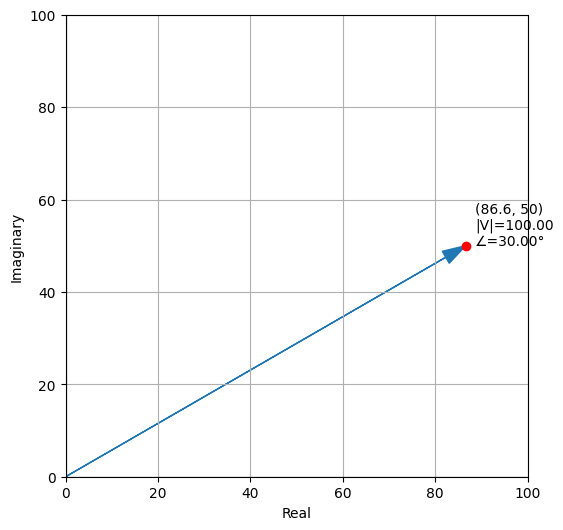

Magnitude = 100.00
Phase angle = 30.00°


In [13]:
import matplotlib.pyplot as plt
import numpy as np

x, y = 86.6, 50

mag = np.hypot(x, y)
phase = np.degrees(np.arctan2(y, x))

fig, ax = plt.subplots(figsize=(6, 6))

ax.axhline(0, color='k', lw=0.8)
ax.axvline(0, color='k', lw=0.8)
ax.grid(True)

ax.arrow(0, 0, x, y,length_includes_head=True,head_width=3,head_length=5,color='tab:blue')

ax.plot(x, y, 'ro')

ax.text(x + 2,y, f'({x}, {y})\n|V|={mag:.2f}\n∠={phase:.2f}°')

ax.set_aspect('equal', 'box')
ax.set_xlabel('Real')
ax.set_ylabel('Imaginary')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100) 

plt.show()

print(f"Magnitude = {mag:.2f}")
print(f"Phase angle = {phase:.2f}°")



If the terminals of the loads are named *a* and *n*, and voltage and current are expressed as: 

$$v_{an} = V_{\max}\cos(\omega t) \qquad i_{an} = I_{\max}\cos(\omega t - \theta)$$

Then the instantaneous power is:

$$p = v_{an}i_{an} = V_{\max}I_{\max}\cos(\omega t)\cos(\omega t - \theta)$$

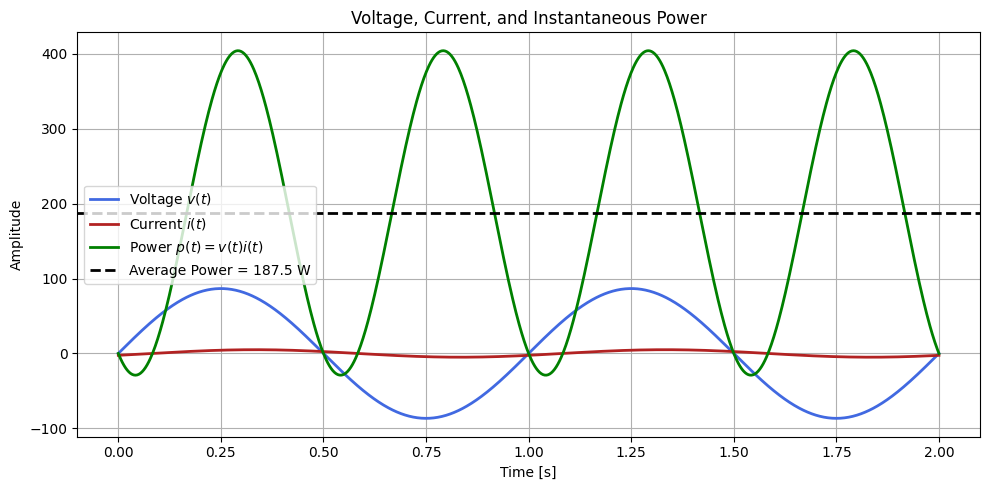

Average Power = 187.49 W


In [18]:
# TEST CELL
# Example 1: Voltage, Current, and Instantaneous Power

import numpy as np
import matplotlib.pyplot as plt

# Parameters
Vmax = 86.6
Imax = 5
f = 1                  # Hz
phi = np.pi / 6        # 30 degree phase shift

# Time axis
t = np.linspace(0, 2, 1000)

# Angular frequency
omega = 2 * np.pi * f

# Waveforms
v = Vmax * np.sin(omega * t)
i = Imax * np.sin(omega * t - phi)

# Instantaneous power
p = v * i

# Average power
Pavg = 0.5 * Vmax * Imax * np.cos(phi)

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t, v, lw=2, color='royalblue', label='Voltage $v(t)$')
ax.plot(t, i, lw=2, color='firebrick', label='Current $i(t)$')
ax.plot(t, p, lw=2, color='green', label='Power $p(t)=v(t)i(t)$')

# Average power line
ax.axhline(
    y=Pavg,
    color='black',
    linestyle='--',
    linewidth=2,
    label=fr'Average Power = {Pavg:.1f} W'
)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Amplitude')
ax.set_title('Voltage, Current, and Instantaneous Power')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

print(f'Average Power = {Pavg:.2f} W')


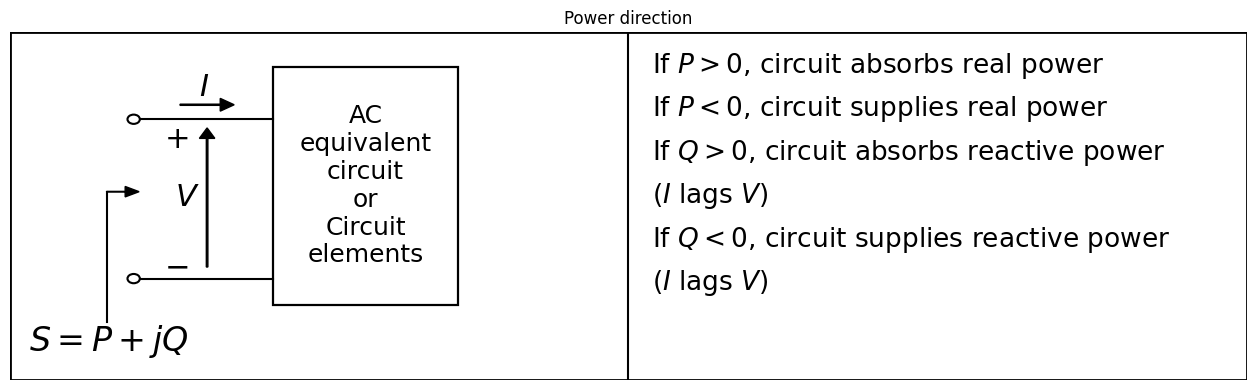

In [86]:
# TEST CELL
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

# Create figure
fig, ax = plt.subplots(figsize=(13, 4))
ax.set_xlim(0, 16)
ax.set_ylim(0, 6)
ax.axis('off')

# Outer border
ax.add_patch(Rectangle((0, 0), 16, 6, fill=False, linewidth=2))

# Vertical divider
ax.plot([8, 8], [0, 6], color='black', linewidth=1.5)

# Circuit block
ax.add_patch(Rectangle((3.4, 1.3), 2.4, 4.1, fill=False, linewidth=1.6))
ax.text(4.6, 3.35, 'AC\nequivalent\ncircuit\nor\nCircuit\nelements', ha='center', va='center', fontsize=18)

# Terminals
ax.add_patch(Circle((1.6, 4.5), 0.08, fill=False, linewidth=1.5))
ax.add_patch(Circle((1.6, 1.75), 0.08, fill=False, linewidth=1.5))

# Connections
ax.plot([1.68, 3.4], [4.5, 4.5], color='black', linewidth=1.5)
ax.plot([1.68, 3.4], [1.75, 1.75], color='black', linewidth=1.5)

# Current arrow
ax.arrow(2.2, 4.75, 0.7, 0, width=0.02, head_width=0.22, head_length=0.18, length_includes_head=True, color='black')
ax.text(2.45, 4.9, r'$I$', fontsize=22)

# Voltage arrow
ax.arrow(2.55, 1.95, 0, 2.4, width=0.02, head_width=0.20, head_length=0.18, length_includes_head=True, color='black')
ax.text(2.15, 4.0, r'$+$', fontsize=22, ha='center')
ax.text(2.15, 1.8, r'$-$', fontsize=22, ha='center')
ax.text(2.3, 3.0, r'$V$', fontsize=22, ha='center')

# Power-flow arrow
ax.plot([1.25, 1.25], [1.0, 3.25], color='black', linewidth=1.5)
ax.arrow(1.25, 3.25, 0.42, 0, width=0.01, head_width=0.18, head_length=0.18, length_includes_head=True, color='black')

# Power equation
ax.text(0.25, 0.5, r'$S=P+jQ$', fontsize=24)

# Right-side text
lines = [
    r'If $P>0$, circuit absorbs real power',
    r'If $P<0$, circuit supplies real power',
    r'If $Q>0$, circuit absorbs reactive power',
    r'($I$ lags $V$)',
    r'If $Q<0$, circuit supplies reactive power',
    r'($I$ lags $V$)',
]

y = 5.3
for line in lines:
    ax.text(8.3, y, line, fontsize=19)
    y -= 0.75
ax.set_title('Power direction')

plt.tight_layout()
plt.show()


## Complex Power

Calculation of real and reactive by using complex form, we use complex conjugate, $Z^*$, because multiplying a complex number by its conjugate gives

\begin{equation}
zz^*=(a+jb)(a-jb)=a^2+b^2=|z|^2
\end{equation}

$$
VI^{*}
= |V|e^{j\alpha}\times|I|e^{-j\beta}
= |V||I|e^{j(\alpha-\beta)}
= |V||I|\angle(\alpha-\beta)
$$

$$
S
= VI^{*}
= |V||I|\cos(\alpha-\beta)
+ j|V||I|\sin(\alpha-\beta)
$$

$$
S = P + jQ
$$

where

$$
P = |V||I|\cos(\alpha-\beta)
$$

and

$$
Q = |V||I|\sin(\alpha-\beta).
$$

## Power triangle

The power triangle depict the relation of $\frac{P}{|S|}$ by the cosine to the angle between them, $\theta$.

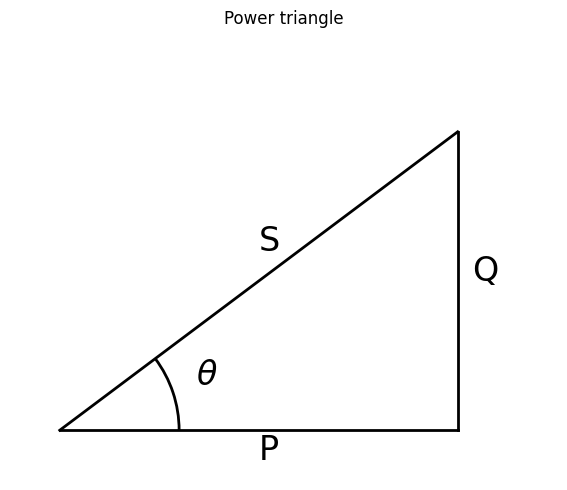

In [84]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

# Example values
P = 8     # Real power
Q = 6      # Reactive power

# Apparent power
S = np.sqrt(P**2 + Q**2)
theta = np.degrees(np.arctan2(Q, P))

fig, ax = plt.subplots(figsize=(8, 5))

# Power triangle
ax.plot([0, P], [0, 0], 'k', lw=2)      # P
ax.plot([P, P], [0, Q], 'k', lw=2)      # Q
ax.plot([0, P], [0, Q], 'k', lw=2)      # S

# Labels
ax.text(P/2, -0.6, 'P', fontsize=24)
ax.text(P + 0.3, Q/2, 'Q', fontsize=24)
ax.text(P*0.5, Q*0.6, 'S', fontsize=24)

# Angle arc
r = min(P, Q) * 0.4
arc = Arc((0, 0), 2*r, 2*r, angle=0, theta1=0, theta2=theta, lw=2)
ax.add_patch(arc)

# Arc arrowhead
x = r * np.cos(np.radians(theta))
y = r * np.sin(np.radians(theta))
#ax.arrow(x - 0.01, y - 0.01, 0.001, 0.001,
#         head_width=0.25, head_length=0.35,
#         fc='black', ec='black')

ax.text(r*1.2*np.cos(np.radians(theta/2)),
        r*1.2*np.sin(np.radians(theta/2)),
        r'$\theta$', fontsize=24)

ax.set_title('Power triangle')
ax.set_aspect('equal')
ax.set_xlim(-1, P + 2)
ax.set_ylim(-1, Q + 2)
ax.axis('off')

plt.tight_layout()
plt.show()


### EXAMPLE 2.1
A 50-kW inductive load is operated at a lagging power factor of 0.8. The supply voltage is 220 V at 60 Hz. Determine the size of the required parallel capacitor to improve the overall power factor to 0.95 lagging.

$P = 50 kw$

$PF_{old} = 0.8$

$PF_{new} = 0.95$

$$
Q = P\tan(\theta).
$$

$$
Q_c = P\left[\tan(\theta_1)-\tan(\theta_2)\right]
$$

Knowing the size of the capacitor, $Q_c$, we know that:

$$ |Q_c| = \frac{V^2}{X_C} $$

and

$$ X_C = \frac{1}{2\pi fC} $$

rearrange

$$ C = \frac{Q_C}{2\pi fC} $$

Below in Python code:

In [79]:
import numpy as np
#Variables
P = 50*10**3          
PF_old = 0.8
PF_new = 0.95

# calc
theta_old = np.degrees(np.arccos(PF_old))
theta_new = np.degrees(np.arccos(PF_new))
print(f"theta_old = {theta_old:.2f} degrees")
print(f"theta_new = {theta_new:.2f} degrees")

Q_c = P * np.tan(np.radians(theta_old)) - P * np.tan(np.radians(theta_new))
print(f"Q_c = {Q_c:.2f} kVAr")

# Given values
V = 220         # Volts
f = 60          # Hz

# Capacitance in Farads
C = Q_c / (2 * np.pi * f * V**2)

# Convert to mF
C_mF = C * 1000

print(f"Capacitance = {C_mF:.4f} mF")

theta_old = 36.87 degrees
theta_new = 18.19 degrees
Q_c = 21065.79 kVAr
Capacitance = 1.1545 mF


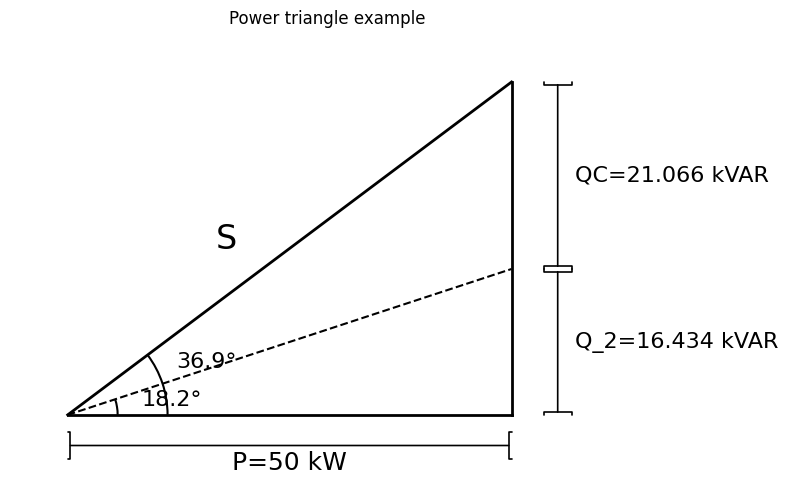

In [85]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

#Variables
P = 50.0          # kW
PF_old = 0.8
PF_new = 0.95

# calc
theta_old = np.degrees(np.arccos(PF_old))
theta_new = np.degrees(np.arccos(PF_new))

Q_old = P * np.tan(np.radians(theta_old))
Q_new = P * np.tan(np.radians(theta_new))
Q_cap = Q_old - Q_new

# Plot limit to scale
xmax = P * 1.3
ymax = Q_old * 1.15

fig, ax = plt.subplots(figsize=(8, 6))

# Original triangle
ax.plot([0, P], [0, 0], 'k', lw=2)
ax.plot([P, P], [0, Q_old], 'k', lw=2)
ax.plot([0, P], [0, Q_old], 'k', lw=2)

# Corrected triangle
ax.plot([0, P], [0, Q_new], color='k', linestyle='--', lw=1.5)

# theta angle indicator
r1 = 0.30 * min(P, Q_old)
r2 = 0.15 * min(P, Q_old)

arc1 = Arc((0, 0), 2*r1, 2*r1, theta1=0, theta2=theta_old, lw=1.5)
arc2 = Arc((0, 0), 2*r2, 2*r2, theta1=0, theta2=theta_new, lw=1.5)

ax.add_patch(arc1)
ax.add_patch(arc2)

# angle labels
ax.text(
    r1*np.cos(np.radians(theta_old/2))*1.15,
    r1*np.sin(np.radians(theta_old/2))*1.5,
    f"{theta_old:.1f}°",
    fontsize=16
)

ax.text(
    r2*np.cos(np.radians(theta_new/2))*1.5,
    r2*np.sin(np.radians(theta_new/2))*1.2,
    f"{theta_new:.1f}°",
    fontsize=16
)

# S label
ax.text(P/3, Q_old/2, 'S', fontsize=24)


offset = ymax * 0.08

ax.annotate(
    '',
    xy=(0, -offset),
    xytext=(P, -offset),
    arrowprops=dict(arrowstyle=']-[', lw=1.2)
)

ax.text(
    P/2,
    -1.8*offset,
    f'P={P:.0f} kW',
    ha='center',
    fontsize=18
)

# new Q
xdim = P + 0.08*xmax

ax.annotate(
    '',
    xy=(xdim, 0),
    xytext=(xdim, Q_new),
    arrowprops=dict(arrowstyle=']-[', lw=1.2)
)

ax.text(
    xdim + 0.03*xmax,
    Q_new/2,
    f'Q_2={Q_new:.3f} kVAR',
    va='center',
    fontsize=16
)

# Capacitor kvar dim
ax.annotate(
    '',
    xy=(xdim, Q_new),
    xytext=(xdim, Q_old),
    arrowprops=dict(arrowstyle=']-[', lw=1.2)
)

ax.text(
    xdim + 0.03*xmax,
    (Q_old + Q_new)/2,
    f'QC={Q_cap:.3f} kVAR',
    va='center',
    fontsize=16
)

ax.set_title('Power triangle example')
ax.set_aspect('equal')
ax.set_xlim(-0.1*xmax, xmax)
ax.set_ylim(-0.15*ymax, ymax)
ax.axis('off')

plt.tight_layout()
plt.show()
